# **Relatório — Laboratório 7**
## *Processamento Morfológico de Imagens* ##

## **Integrantes**
- Matheus Foresto Moselli
- Marcos Vinicius Medeiros da Silva
- Karl Eloy Marques Henrique

**Data do experimento:** 24/03/2026
**Data de publicação do relatório:** 07/04/2026

---

## **1. Introdução**
O processamento morfológico de imagens é uma ferramenta baseada na teoria dos conjuntos, utilizada para extrair componentes da imagem que são úteis na representação e descrição da forma de regiões. As operações fundamentais são a **Erosão** (que reduz objetos e remove detalhes finos) e a **Dilatação** (que expande objetos e preenche lacunas).

A partir dessas operações primárias, derivam-se a **Abertura** (erosão seguida de dilatação), eficaz para remover ruídos e pequenos objetos, e o **Fechamento** (dilatação seguida de erosão), ideal para fechar pequenos buracos e unir componentes próximos. Neste laboratório, exploramos a aplicação desses operadores em imagens binárias dos integrantes do grupo e imagens do projeto final, utilizando a biblioteca `morph.py`.

---

## **2. Procedimentos Experimentais**
Para a realização das atividades, foram seguidos os seguintes passos:

1.  **Configuração do Ambiente:** Importação das bibliotecas `OpenCV`, `NumPy`, `Matplotlib` e a biblioteca específica `morph.py` para operações morfológicas.
2.  **Preparação das Imagens:**
    - Leitura das imagens de grupo e do projeto final (detecção de comprimidos).
    - Conversão das imagens para escala de cinza via `mm.gray`.
    - **Binarização:** Aplicação de limiarização (`mm.threshold`) para converter as imagens em formato binário, requisito essencial para o processamento morfológico.
3.  **Aplicação dos Operadores:**
    - Utilização das funções `mm.erode`, `mm.dilate`, `mm.open` e `mm.close`.
    - Teste de diferentes tamanhos de **Elementos Estruturantes (Kernels)**, variando de 3x3 até 21x21, para observar o impacto da escala na filtragem.
4.  **Processamento do Projeto Final:** Implementação de uma função para extrair o gradiente morfológico e aplicar abertura/fechamento em imagens de interesse do projeto da equipe.

---

## **3. Análise e Discussão**

### **Influência do Tamanho do Kernel**
O tamanho do elemento estruturante foi determinante no resultado visual:
* **Kernels pequenos (3x3, 5x5):** Preservaram melhor os detalhes finos, mas foram menos eficazes na remoção de ruídos de fundo mais densos.
* **Kernels grandes (acima de 11x11):** Causaram alterações drásticas. Na erosão, partes finas dos objetos (como dedos ou detalhes do avatar) desapareceram. Na dilatação, objetos próximos se fundiram, perdendo a separação original.

### **Impacto da Binarização**
A binarização foi a etapa mais crítica. Como as operações morfológicas atuam sobre a geometria, a escolha do limiar define o que é considerado "objeto". Um limiar inadequado resultou em perdas de informação que as operações morfológicas não conseguiram recuperar posteriormente. O uso do `mm.threshold` com valor zero (ajustado conforme a necessidade) mostrou-se o ponto de partida ideal para as transformações.

### **Resultados no Projeto Final**
Na aplicação sobre as imagens do projeto de detecção de comprimidos, a operação de **Abertura** eliminou pequenos artefatos de ruído no fundo, enquanto o **Gradiente Morfológico** (diferença entre dilatação e erosão) foi fundamental para destacar as bordas dos objetos, facilitando a visualização dos contornos.

---

## **4. Conclusões**
Os experimentos demonstraram que o processamento morfológico é uma técnica robusta para o pré-processamento de imagens binárias. A combinação correta de operações (abertura e fechamento) permite filtrar ruídos e suavizar formas sem comprometer a estrutura principal do objeto, desde que o tamanho e o formato do elemento estruturante sejam adequados à escala dos detalhes que se deseja processar.

---

## **5. Referências**
- OPENCV. **Image Thresholding**. Disponível em: https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html. Acesso em: 3 abr. 2026.
- GONZALEZ, Rafael C.; WOODS, Richard E. **Digital Image Processing**. 4. ed. Pearson, 2018.
- MALLICK, Satya. **Image Thresholding using OpenCV**. Disponível em: https://learnopencv.com/opencv-threshold-python-cpp/. Acesso em: 5 abr. 2026.



**2.1 - Exercícios realizados**

**3a)** Elabore um programa para realizar as operações de EROSÃO, DILATAÇÃO, ABERTURA, e FECHAMENTO, sobre as imagens em grupo dos integrantes da equipe bem como nos avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem, experimentado diversos tamanhos (3x3 até 21x21) de Elemento Estruturante – KERNEL - e compare-as entre si, quanto ao aspecto visual (filtragem, aparência, representação, etc) da
imagens resultantes. Lembre-se de binarizar as imagens antes da aplicação dos operadores. Assim, dentro desta análise, discuta se a binarização influiu no resultado e qual método foi mais interessante para sua aplicação.

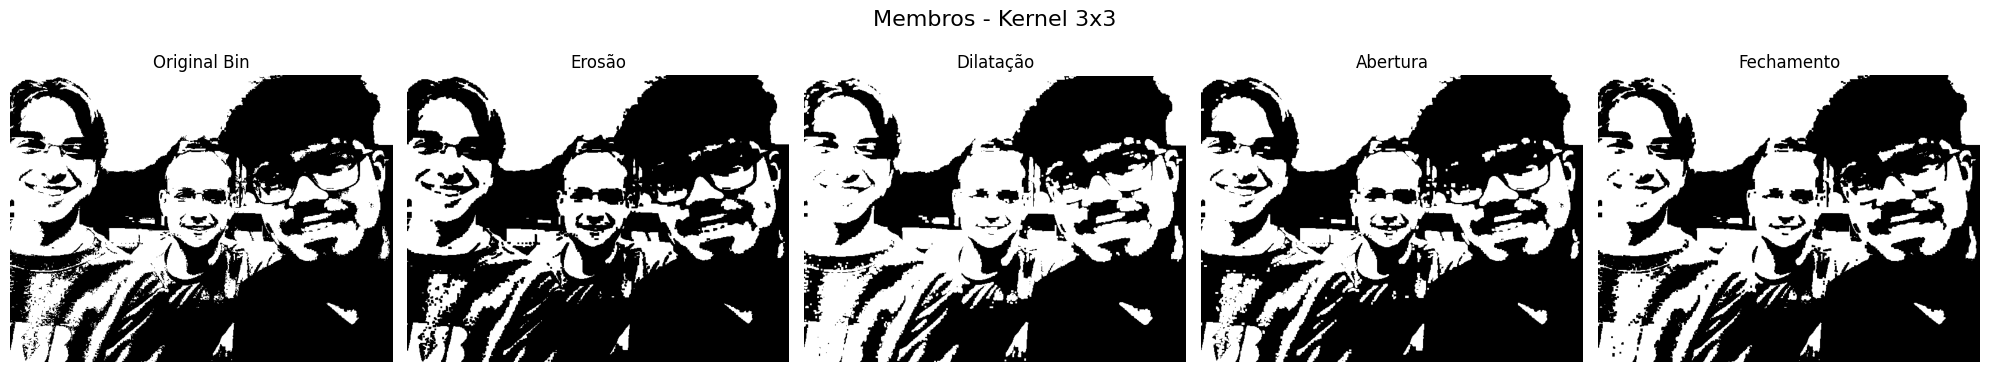

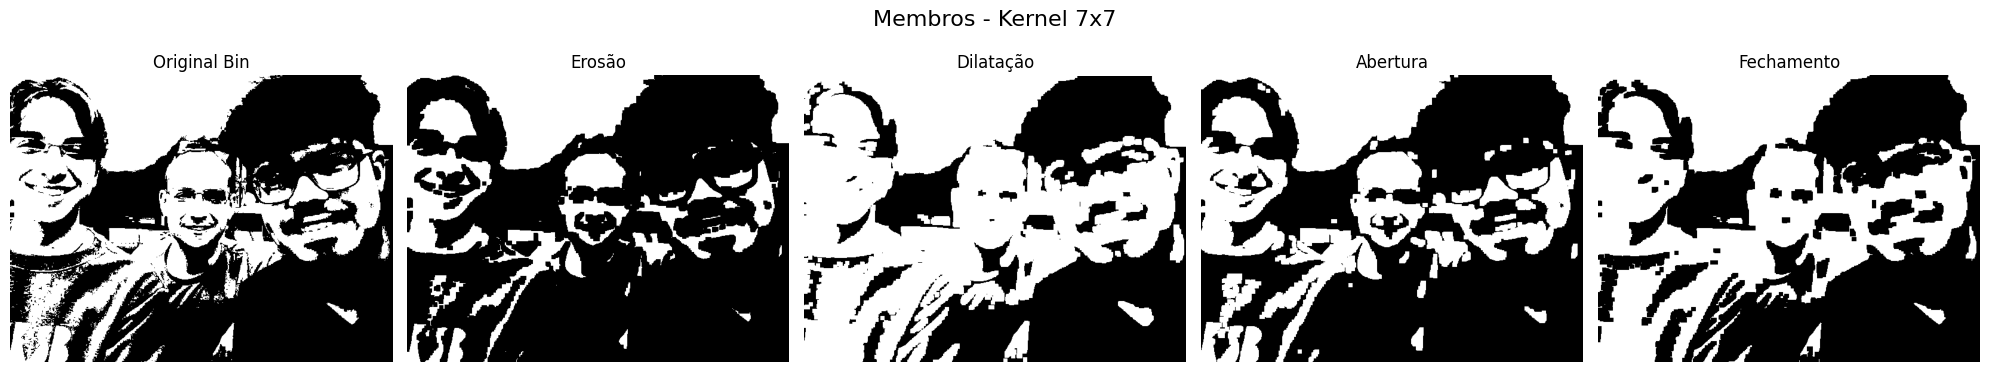

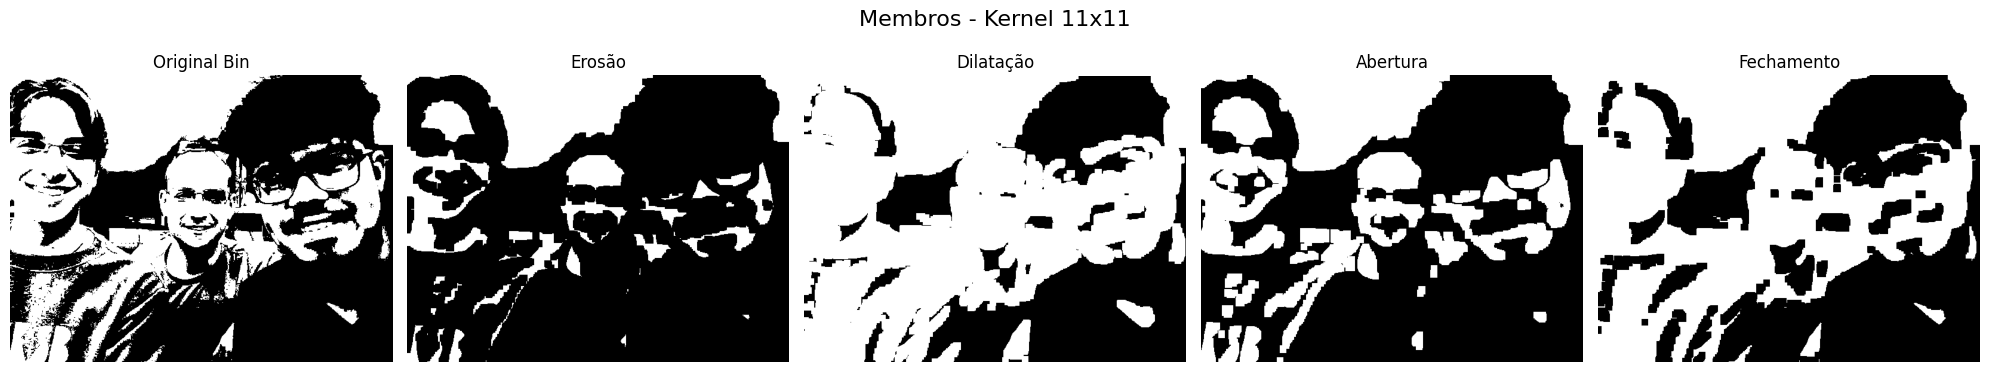

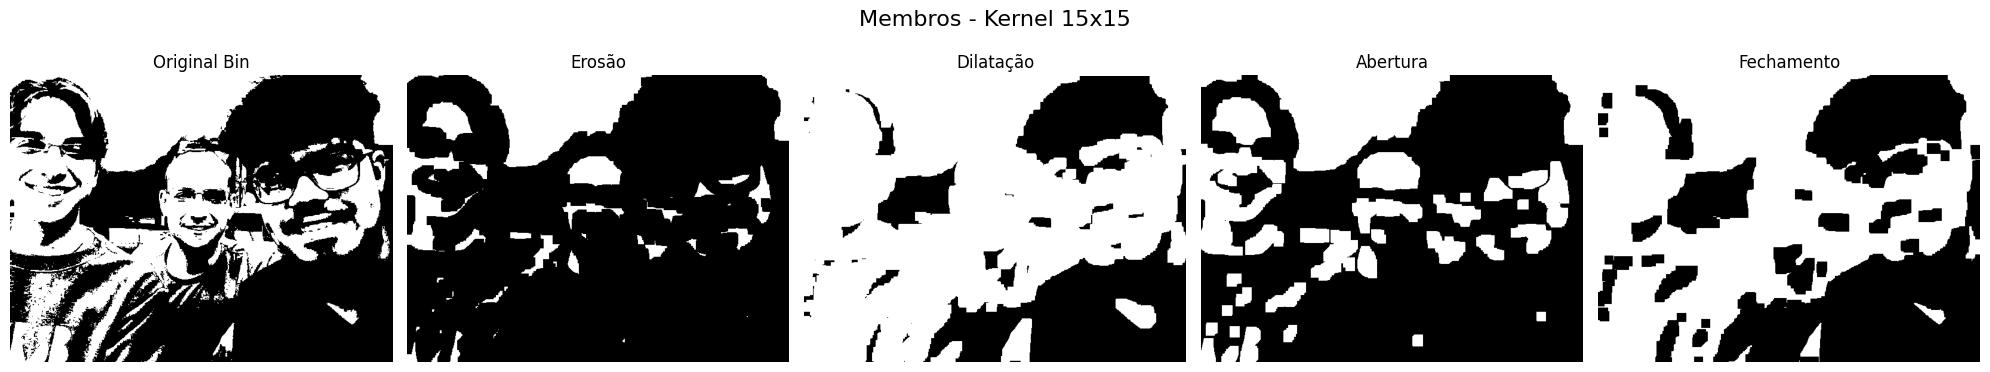

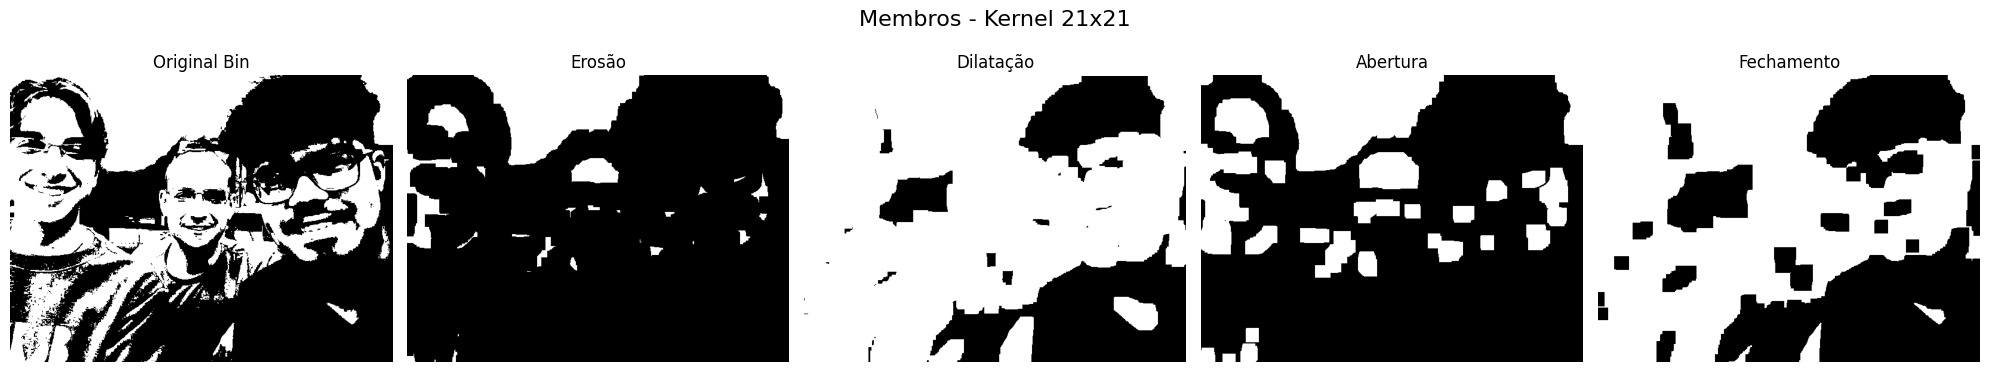

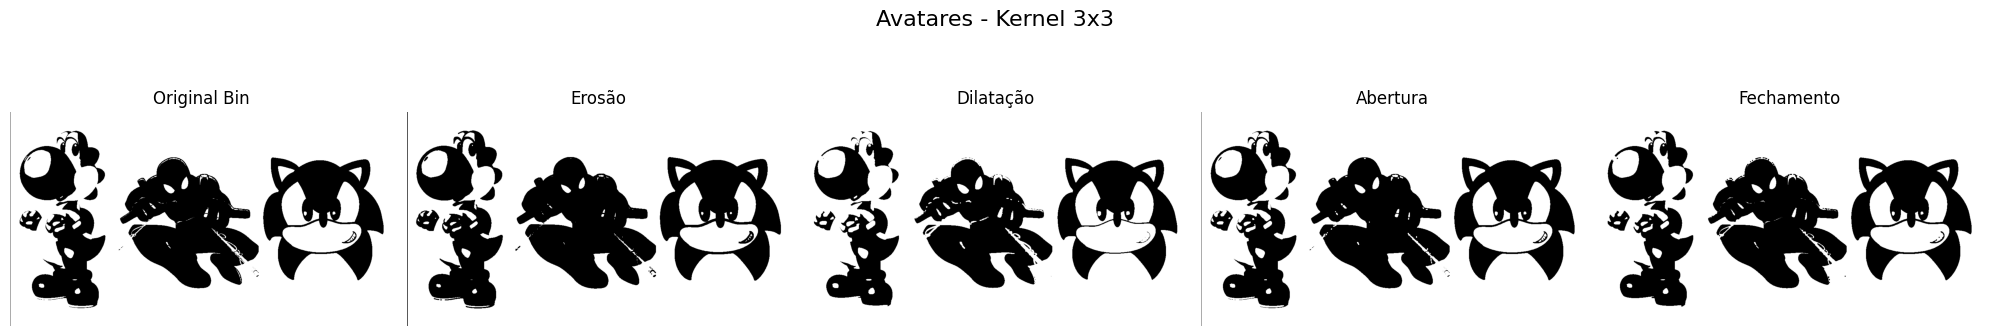

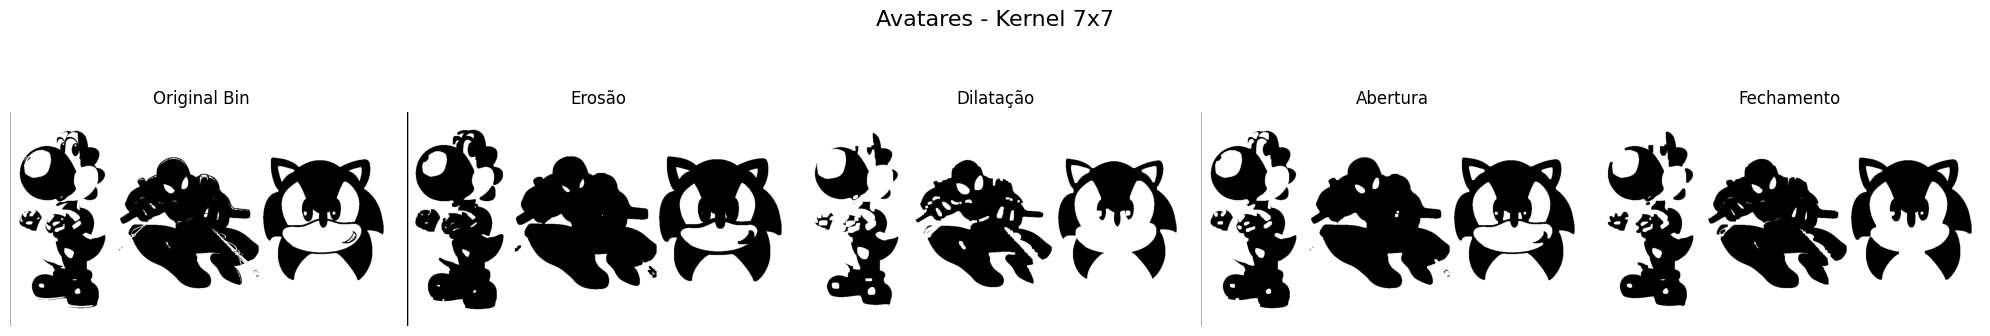

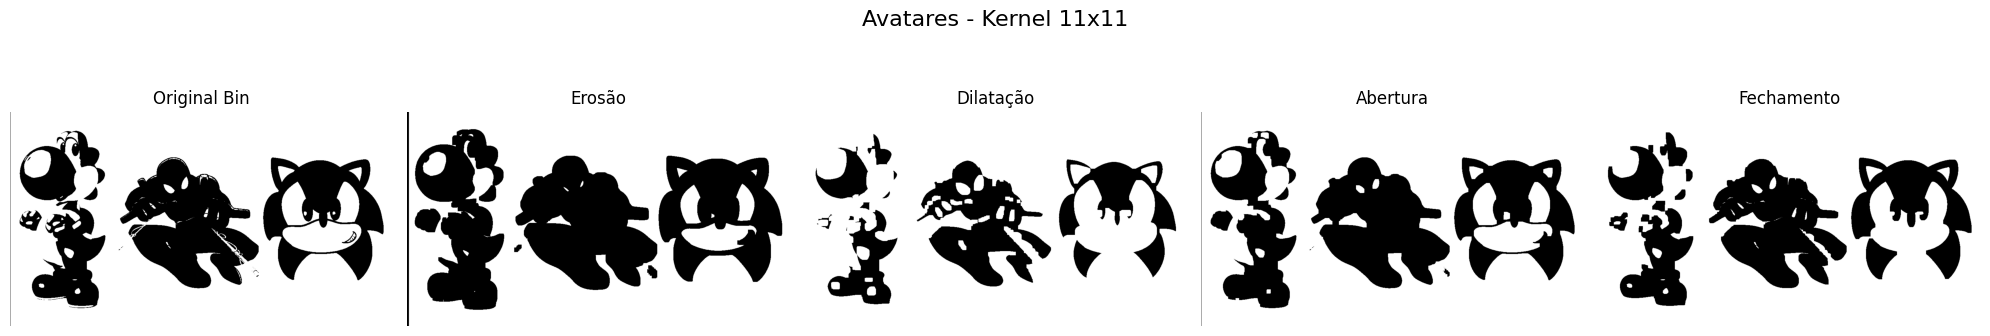

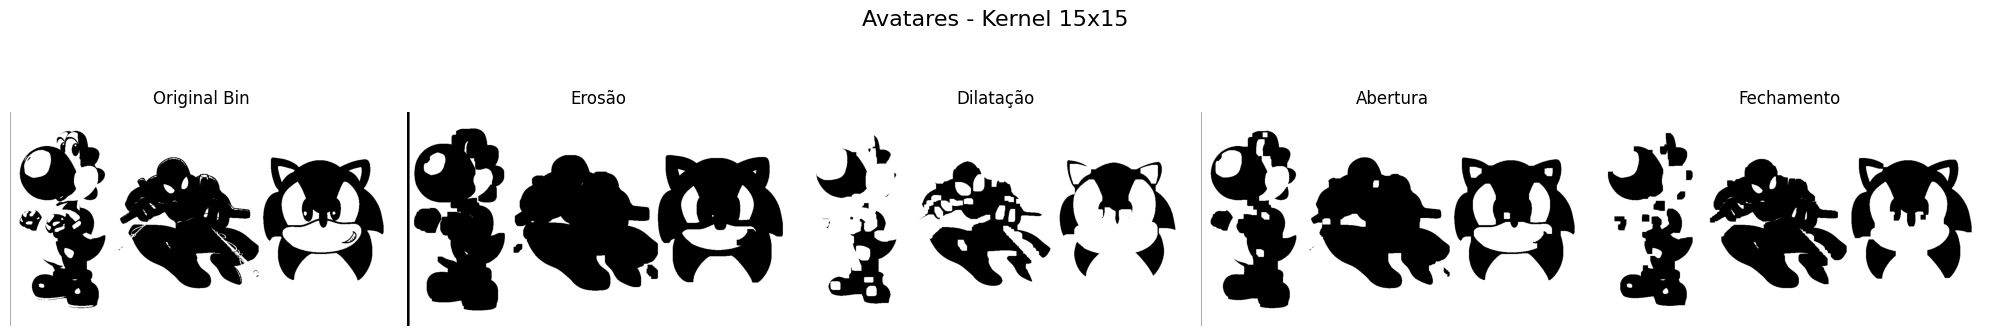

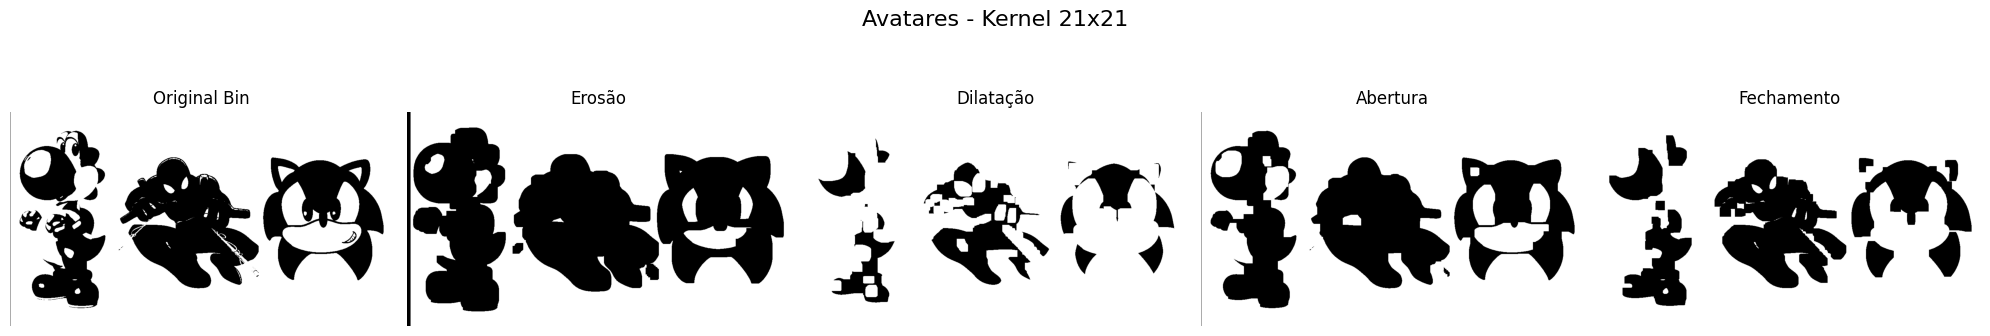

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import *

mm.install()

## Ex 3a

img_membros = mm.read('images_grupo/alunos.png') 
img_avatares = mm.read('images_grupo/avatares.png')

def operacoes_edaf_com_variacao(img_input, titulo_prefixo):
    img_rgb = mm.color(img_input)
    img_gray = mm.gray(img_rgb)
    
    img_bin = mm.threshold(img_gray, 0)

    tamanhos_kernel = [3, 7, 11, 15, 21]
    
    for k_size in tamanhos_kernel:
        kernel = np.ones((k_size, k_size), np.uint8)
        
        operacoes = {
            "Erosão": mm.ero(img_bin, kernel),
            "Dilatação": mm.dil(img_bin, kernel),
            "Abertura": mm.open(img_bin, kernel),
            "Fechamento": mm.close(img_bin, kernel)
        }

        plt.figure(figsize=(20, 4))
        plt.suptitle(f"{titulo_prefixo} - Kernel {k_size}x{k_size}", fontsize=16)
        
        plt.subplot(1, 5, 1)
        plt.imshow(img_bin, cmap='gray')
        plt.title("Original Bin")
        plt.axis('off')

        for i, (nome, resultado) in enumerate(operacoes.items(), 2):
            plt.subplot(1, 5, i)
            plt.imshow(resultado, cmap='gray')
            plt.title(f"{nome}")
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()

operacoes_edaf_com_variacao(img_membros, "Membros")
operacoes_edaf_com_variacao(img_avatares, "Avatares")

### **Erosão**
* **Aspecto Visual:** Atua reduzindo as áreas brancas (objetos).
* **Análise por Kernel:** No tamanho **3x3**, a erosão eliminou pixels isolados. Conforme o kernel aumentou para **21x21**, partes essenciais das silhuetas desapareceram, restando apenas o "núcleo" das formas mais densas.
* **Representação:** É eficaz para separar objetos que estão levemente encostados, mas torna-se destrutiva em kernels grandes.

### **Dilatação**
* **Aspecto Visual:** Expande as regiões brancas, preenchendo lacunas.
* **Análise por Kernel:** Em kernels pequenos, ajudou a solidificar as formas. Porém, a partir do **11x11**, os rostos dos membros da equipe e os corpos dos avatares começaram a se fundir. No **21x21**, a imagem virou uma massa branca contínua, perdendo a distinção individual.
* **Representação:** Útil para conectar partes de um objeto que foram separadas erroneamente na binarização.

### **Abertura (Erosão seguida de Dilatação)**
* **Aspecto Visual:** Remove pequenos objetos brancos e suaviza contornos.
* **Análise por Kernel:** Foi o operador de "limpeza" mais eficiente. Mesmo em kernels maiores (**15x15**), ele conseguiu remover texturas ruidosas do fundo sem alterar drasticamente o volume total dos alunos.
* **Representação:** Ideal para eliminar ruído tipo "sal" sem deformar o tamanho original dos objetos principais.

### **Fechamento (Dilatação seguida de Erosão)**
* **Aspecto Visual:** Fecha buracos pretos e canais dentro das formas brancas.
* **Análise por Kernel:** Nos **Avatares**, transformou desenhos com contornos em silhuetas sólidas (eliminando olhos e detalhes internos). Nos **Membros**, ajudou a unir falhas causadas por sombras ou reflexos nas roupas.
* **Representação:** Melhora a conectividade interna e a solidez da representação visual.



| Característica | Imagem "Membros" | Imagem "Avatares" |
| :--- | :--- | :--- |
| **Sensibilidade** | Alta. Kernels acima de 11x11 destruiram as feições dos integrantes do grupo. | Média. As formas são mais robustas e suportam kernels maiores. |
| **Melhor Kernel** | **3x3 ou 7x7**. Preservou a identidade visual. | **11x11**. Simplificou a imagem em silhuetas dos personagens. |
| **Filtragem** | A abertura limpou o ruído de fundo da foto. | O fechamento unificou os contornos dos personagens. |
---

É possível afirmar categoricamente que a binarização influenciou no resultado. Como a morfologia opera sobre lógica de pixels ligados/desligados, a qualidade da binarização define o que o kernel considera "objeto". Na imagem dos membros, o excesso de brilho em certas partes do cenário foi binarizado como branco, fazendo com que a dilatação unisse os alunos ao fundo indesejado.

Para fins de **limpeza e filtragem**, a **Abertura com Kernel 7x7** foi a mais interessante, pois removeu os ruídos granulados típicos de fotos reais sem causar a distorção severa vista nos kernels de 21x21. Para fins de **reconhecimento de formas**, o **Fechamento com Kernel 11x11** nos Avatares mostrou-se superior, gerando máscaras sólidas prontas para processamentos posteriores de visão computacional.

**3b)** Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de Extração de Fronteiras (Gradiente Morfológico), mostrando na tela em tempo
real lado-a-lado a imagem original e a imagem extraída, permitindo ao operador escolher
– via teclado – a extração com diversos tamanhos de kernel. Grave um video demonstrativo
com os integrantes da equipe utilizando este programa com a webcam. Elabore uma
análise detalhada e explique os artefatos ocorridos.
Obs. O comando cv2.hconcat() une duas ou mais imagens horizontalmente (lado a lado),
desde que tenham a mesma altura. Ex.: resultado = cv2.hconcat([img1, img2])

In [ ]:
import cv2
import numpy as np
from morph import mm

cap = cv2.VideoCapture(0)
k_size = 3
gravando = False
out = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = mm.color(frame)
    img_gray = mm.gray(img_rgb)
    img_bin = mm.threshold(img_gray, 0)
    
    kernel = np.ones((k_size, k_size), np.uint8)
    fronteira = mm.gradm(img_bin, kernel)
    
    fronteira_bgr = cv2.cvtColor(fronteira, cv2.COLOR_GRAY2BGR)
    resultado = cv2.hconcat([frame, fronteira_bgr])
    
    cv2.putText(resultado, f"Kernel: {k_size}x{k_size}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    if gravando and out is not None:
        out.write(resultado)

    cv2.imshow('Lab7 - Gradiente Morfologico', resultado)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        gravando = not gravando
        if gravando:
            h, w, _ = resultado.shape
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter('video_saida.avi', fourcc, 20.0, (w, h))
        else:
            out.release()
    elif key == ord('1'): k_size = 3
    elif key == ord('2'): k_size = 7
    elif key == ord('3'): k_size = 11
    elif key == ord('4'): k_size = 15
    elif key == ord('5'): k_size = 21

cap.release()
if out is not None:
    out.release()
cv2.destroyAllWindows()